# 04 · Análisis de Correspondencias Múltiples (MCA) del estimado

## Estructura latente de finca, producto y color en los estimados H1

Los notebooks anteriores describen cómo se construye el estimado (`01`), cómo se integra con el resto de la base (`02`) y qué tan bien acierta frente a la producción real (`03`). Aquí cambiamos de pregunta: **¿cómo se estructura el catálogo que el ingeniero estima?** Es decir, qué combinaciones de *finca*, *producto* y *color* tienden a aparecer juntas y qué ejes de variación organizan ese catálogo.

El **Análisis de Correspondencias Múltiples (MCA)** es la extensión del Análisis de Correspondencias a más de dos variables categóricas. Es el análogo del PCA para datos puramente cualitativos: proyecta las categorías (y las observaciones) sobre unos pocos ejes que maximizan la inercia —la dispersión— recogida, de modo que categorías que co-ocurren quedan cerca en el mapa y categorías que se excluyen quedan lejos.

**Caveat de lectura.** El MCA describe el **diseño del estimado**, no la demanda real ni la calidad de la predicción. Que dos categorías estén próximas en el plano significa que el ingeniero las estima juntas, no que exista una relación causal ni que el estimado sea correcto.

## 0. Preparación

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", palette="colorblind")

RAIZ = Path.cwd()
if not (RAIZ / "Notebooks").exists():
    RAIZ = RAIZ.parent
RUTA_ESTIMADOS = RAIZ / "Notebooks" / "estimados_H1.xlsx"

print("Raiz del proyecto:", RAIZ)
print("Fuente de estimados:", RUTA_ESTIMADOS.relative_to(RAIZ))

Raiz del proyecto: /Users/anderson.gonzalez/Downloads/Proyecto-de-grado_LGF-main
Fuente de estimados: Notebooks/estimados_H1.xlsx


### 0.1. Carga y selección de variables

**Variables activas** (definen los ejes): `CODFINCA`, `PRODUCTO`, `COLOR`. Los colores con frecuencia inferior al 1 % se agrupan en `Otros` para evitar categorías dominadas por el ruido.

**Variables suplementarias** (se proyectan sobre los ejes ya construidos, sin influir en ellos): el **volumen** estimado (`ESTI. EXPORTABLE`) discretizado en cinco tramos y el **trimestre** de la semana objetivo. Sirven para leer el mapa, no para construirlo.

Se excluyen: `VARIEDAD` (150 categorías, demasiado dispersa para un mapa legible) y las columnas constantes en H1 (`TIPO`, `AÑO`, `horizonte`, `semanas_adelante`, `variedades validas`).

In [2]:
df = pd.read_excel(RUTA_ESTIMADOS)
print(f"Filas: {len(df):,}   Columnas: {df.shape[1]}")

# --- Variables suplementarias derivadas ---
df["vol_cat"] = pd.cut(
    df["ESTI. EXPORTABLE"],
    bins=[-1, 0, 1_320, 5_810, 12_080, np.inf],
    labels=["Cero", "Bajo", "Medio", "Alto", "Muy alto"],
)
df["trimestre"] = pd.cut(
    df["semana_objetivo"],
    bins=[0, 13, 26, 39, 53],
    labels=["T1", "T2", "T3", "T4"],
).cat.remove_unused_categories()

# --- Agrupacion de colores raros ---
frec_color = df["COLOR"].value_counts(normalize=True)
colores_raros = frec_color[frec_color < 0.01].index
df["COLOR_grp"] = df["COLOR"].where(~df["COLOR"].isin(colores_raros), "Otros")
print(f"Colores agrupados en 'Otros': {list(colores_raros)}")

VARS_ACTIVAS = ["CODFINCA", "PRODUCTO", "COLOR_grp"]
VARS_SUP = ["vol_cat", "trimestre"]

X = df[VARS_ACTIVAS].astype("object")
X_sup = df[VARS_SUP].astype("object")

resumen_cardinalidad = pd.DataFrame(
    {"n_categorias": [df[c].nunique() for c in VARS_ACTIVAS + VARS_SUP],
     "rol": ["activa"] * len(VARS_ACTIVAS) + ["suplementaria"] * len(VARS_SUP)},
    index=VARS_ACTIVAS + VARS_SUP,
)
display(resumen_cardinalidad)

Filas: 7,282   Columnas: 22
Colores agrupados en 'Otros': ['Pink', 'Dark Pink']


,n_categorias,rol
CODFINCA,3,activa
PRODUCTO,14,activa
COLOR_grp,21,activa
vol_cat,5,suplementaria
trimestre,3,suplementaria


## 1. Fundamento del método

Sea $Z$ la **matriz indicadora** (*one-hot*) de las $Q$ variables activas: $N$ filas (observaciones) y $J$ columnas (todas las categorías de todas las variables). El MCA es un Análisis de Correspondencias sobre $Z$:

1. Se pasa a frecuencias relativas $P = Z / \sum Z$ y se calculan los márgenes de fila $r$ y de columna $c$.
2. Se forma la matriz de residuos estandarizados $S = D_r^{-1/2}\,(P - r c^{\top})\,D_c^{-1/2}$.
3. Su descomposición en valores singulares $S = U \Sigma V^{\top}$ da los ejes. Los **autovalores** son $\lambda_k = \sigma_k^2$.

La **inercia total** del MCA es siempre $\dfrac{J - Q}{Q}$, un valor que depende sólo del número de categorías. Por eso el porcentaje de inercia "crudo" de cada eje resulta artificialmente bajo y **subestima** la estructura real. Se corrige con:

- **Benzécri:** sólo cuenta los ejes con $\lambda_k > 1/Q$ y los reescala como $\big[\tfrac{Q}{Q-1}(\lambda_k - \tfrac{1}{Q})\big]^2$.
- **Greenacre:** igual numerador, pero divide por una inercia total ajustada (más conservadora que Benzécri). Es la corrección recomendada para reportar "varianza explicada".

Las **contribuciones** indican qué categorías construyen cada eje; el **cos²** mide qué tan bien queda representada cada categoría en el plano elegido.

## 2. Motor MCA (numpy)

Implementación directa con `numpy`, sin dependencias adicionales. Devuelve coordenadas principales de categorías y de observaciones, autovalores, contribuciones, cos², las tres versiones del porcentaje de inercia y la proyección de las categorías suplementarias.

In [3]:
def ajustar_mca(X, X_sup=None, tol=1e-8):
    """MCA por SVD de la matriz indicadora. Devuelve un dict con las piezas del analisis."""
    Z = pd.get_dummies(X, prefix_sep="=").astype(float)
    categorias = Z.columns.to_numpy()
    var_de_categoria = np.array([c.split("=", 1)[0] for c in categorias])
    Q = X.shape[1]
    N, J = Z.shape

    P = Z.to_numpy()
    P = P / P.sum()
    r = P.sum(axis=1)
    c = P.sum(axis=0)
    dr = 1.0 / np.sqrt(r)
    dc = 1.0 / np.sqrt(c)

    S = dr[:, None] * (P - np.outer(r, c)) * dc[None, :]
    U, sigma, Vt = np.linalg.svd(S, full_matrices=False)

    keep = sigma > tol
    U, sigma, Vt = U[:, keep], sigma[keep], Vt[keep, :]
    eig = sigma ** 2

    # Coordenadas principales
    coords_col = dc[:, None] * Vt.T * sigma[None, :]   # J x K  (categorias)
    coords_row = dr[:, None] * U * sigma[None, :]      # N x K  (observaciones)

    # Contribuciones de cada categoria al eje (suman 1 por eje)
    contrib = (c[:, None] * coords_col ** 2) / eig[None, :]
    # Calidad de representacion (cos^2) de cada categoria
    dist2 = (coords_col ** 2).sum(axis=1)
    cos2 = coords_col ** 2 / dist2[:, None]

    # --- Correcciones de inercia ---
    inercia_total = eig.sum()                    # = (J - Q) / Q
    mask = eig > 1.0 / Q
    eig_bz = np.where(mask, ((Q / (Q - 1.0)) * (eig - 1.0 / Q)) ** 2, 0.0)
    total_bz = eig_bz.sum()
    total_greenacre = (Q / (Q - 1.0)) * ((eig ** 2).sum() - (J - Q) / Q ** 2)

    out = {
        "categorias": categorias,
        "var_de_categoria": var_de_categoria,
        "Q": Q, "N": N, "J": J,
        "eig": eig, "sigma": sigma,
        "coords_col": coords_col,
        "coords_row": coords_row,
        "contrib": contrib,
        "cos2": cos2,
        "inercia_total": inercia_total,
        "inercia_pct": eig / inercia_total * 100,
        "inercia_pct_benzecri": np.where(mask, eig_bz / total_bz * 100, 0.0),
        "inercia_pct_greenacre": np.where(mask, eig_bz / total_greenacre * 100, 0.0),
    }

    if X_sup is not None:
        Zs = pd.get_dummies(X_sup, prefix_sep="=").astype(float)
        proy = {}
        for col in Zs.columns:
            ind = Zs[col].to_numpy()
            w = ind / ind.sum()
            # coord. principal suplementaria = baricentro de coords_row / sigma
            proy[col] = (w @ coords_row) / sigma
        out["coords_sup"] = pd.DataFrame(
            proy, index=[f"Dim{k + 1}" for k in range(len(sigma))]
        ).T
        out["var_de_sup"] = np.array([s.split("=", 1)[0] for s in Zs.columns])

    return out


mca = ajustar_mca(X, X_sup)
print(f"Observaciones (N): {mca['N']:,}")
print(f"Categorias activas (J): {mca['J']}")
print(f"Variables activas (Q): {mca['Q']}")
print(f"Ejes no triviales: {len(mca['eig'])}")

Observaciones (N): 7,282
Categorias activas (J): 38
Variables activas (Q): 3
Ejes no triviales: 34


In [4]:
# --- Validaciones numericas ---
J, Q = mca["J"], mca["Q"]
assert abs(mca["inercia_total"] - (J - Q) / Q) < 1e-6, "inercia total != (J-Q)/Q"
assert np.allclose(mca["contrib"].sum(axis=0), 1.0), "las contribuciones no suman 1 por eje"
assert mca["coords_row"].shape[0] == len(df), "faltan observaciones en coords_row"
assert mca["coords_col"].shape[0] == J, "faltan categorias en coords_col"
print("Inercia total (cruda):", round(mca["inercia_total"], 4),
      " =  (J - Q) / Q =", round((J - Q) / Q, 4))
print("Validaciones OK.")

Inercia total (cruda): 11.6667  =  (J - Q) / Q = 11.6667
Validaciones OK.


## 3. Inercia y elección de dimensiones

In [5]:
n_ver = 10
tabla_inercia = pd.DataFrame({
    "autovalor": mca["eig"][:n_ver],
    "%_inercia_cruda": mca["inercia_pct"][:n_ver],
    "%_benzecri": mca["inercia_pct_benzecri"][:n_ver],
    "%_greenacre": mca["inercia_pct_greenacre"][:n_ver],
}, index=[f"Dim{k + 1}" for k in range(n_ver)])
tabla_inercia["%_greenacre_acum"] = tabla_inercia["%_greenacre"].cumsum()
display(tabla_inercia)

,autovalor,%_inercia_cruda,%_benzecri,%_greenacre,%_greenacre_acum
Dim1,0.753,6.453,49.596,40.603,40.603
Dim2,0.585,5.017,17.884,14.641,55.244
Dim3,0.531,4.551,11.006,9.010,64.254
Dim4,0.482,4.132,6.235,5.104,69.359
Dim5,0.461,3.948,4.560,3.734,73.092
Dim6,0.430,3.686,2.635,2.157,75.249
Dim7,0.428,3.665,2.502,2.048,77.297
Dim8,0.420,3.601,2.123,1.738,79.035
Dim9,0.399,3.424,1.231,1.008,80.043
Dim10,0.394,3.379,1.044,0.855,80.898


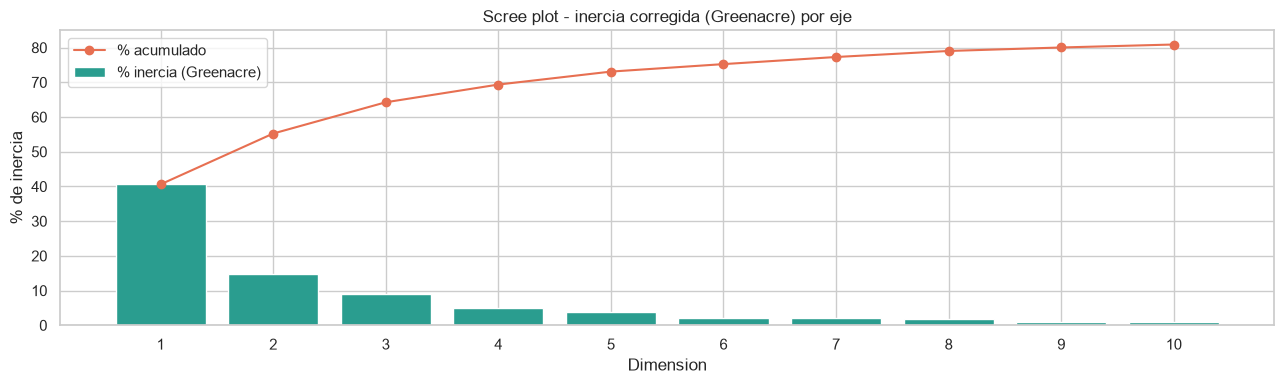

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ejes = np.arange(1, n_ver + 1)
ax.bar(ejes, mca["inercia_pct_greenacre"][:n_ver], color="#2A9D8F", label="% inercia (Greenacre)")
ax.plot(ejes, np.cumsum(mca["inercia_pct_greenacre"][:n_ver]), color="#E76F51",
        marker="o", label="% acumulado")
ax.set(title="Scree plot - inercia corregida (Greenacre) por eje",
       xlabel="Dimension", ylabel="% de inercia")
ax.set_xticks(ejes)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
umbral = 1.0 / Q
n_sobre_umbral = int((mca["eig"] > umbral).sum())
acum2 = np.cumsum(mca["inercia_pct_greenacre"])[1]
display(Markdown(
    f"**Lectura de negocio.** Con $Q={Q}$ variables activas, el umbral de Benzécri es "
    f"$1/Q = {umbral:.3f}$; sólo **{n_sobre_umbral} ejes** lo superan y aportan estructura real. "
    f"La corrección de Greenacre concentra la inercia en las dos primeras dimensiones "
    f"({acum2:.1f} % acumulado), que es el plano que se interpreta a continuación. "
    f"La tercera dimensión se revisa como complemento."
))

**Lectura de negocio.** Con $Q=3$ variables activas, el umbral de Benzécri es $1/Q = 0.333$; sólo **17 ejes** lo superan y aportan estructura real. La corrección de Greenacre concentra la inercia en las dos primeras dimensiones (55.2 % acumulado), que es el plano que se interpreta a continuación. La tercera dimensión se revisa como complemento.

## 4. Mapa de categorías (dimensiones 1-2)

Cada punto es una categoría. Categorías próximas co-ocurren en los estimados; categorías alejadas del centro son las que más diferencian el catálogo. Las cruces negras son las categorías **suplementarias** (volumen y trimestre), proyectadas sin influir en los ejes.

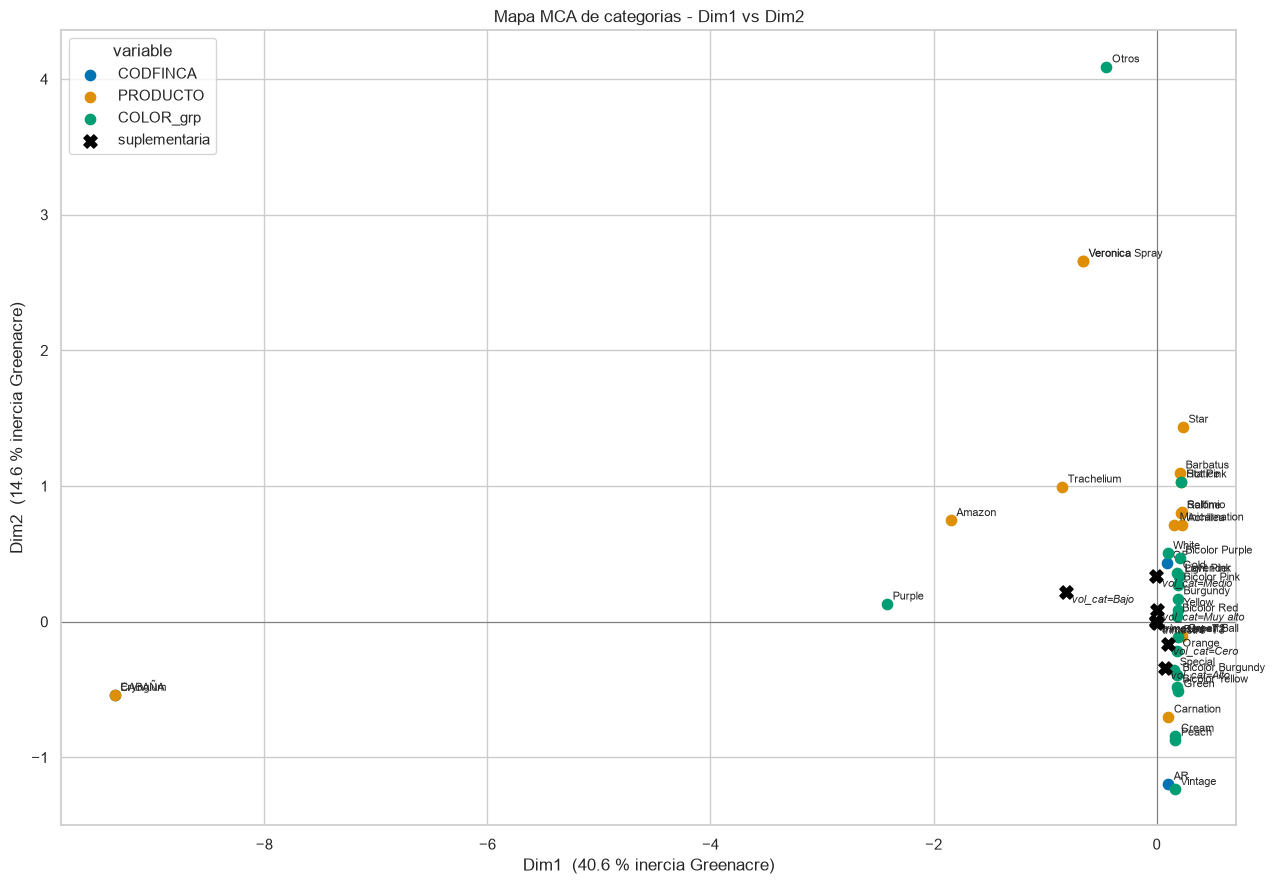

In [8]:
def mapa_categorias(mca, dim_x=0, dim_y=1, con_sup=True, recorte=None, figsize=(13, 9)):
    G = mca["coords_col"]
    cats = mca["categorias"]
    varcat = mca["var_de_categoria"]
    variables = list(dict.fromkeys(varcat))
    paleta = dict(zip(variables, sns.color_palette("colorblind", len(variables))))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color="grey", lw=0.8)
    ax.axvline(0, color="grey", lw=0.8)

    for v in variables:
        m = varcat == v
        ax.scatter(G[m, dim_x], G[m, dim_y], s=55, color=paleta[v], label=v, zorder=3)
        for x, y, etq in zip(G[m, dim_x], G[m, dim_y], cats[m]):
            ax.annotate(etq.split("=", 1)[1], (x, y), fontsize=8,
                        xytext=(4, 3), textcoords="offset points")

    if con_sup and "coords_sup" in mca:
        Ssup = mca["coords_sup"]
        ax.scatter(Ssup.iloc[:, dim_x], Ssup.iloc[:, dim_y], marker="X", s=90,
                   color="black", label="suplementaria", zorder=4)
        for etq, row in Ssup.iterrows():
            ax.annotate(etq, (row.iloc[dim_x], row.iloc[dim_y]), fontsize=8,
                        xytext=(4, -8), textcoords="offset points", style="italic")

    px, py = mca["inercia_pct_greenacre"][dim_x], mca["inercia_pct_greenacre"][dim_y]
    ax.set(title=f"Mapa MCA de categorias - Dim{dim_x + 1} vs Dim{dim_y + 1}",
           xlabel=f"Dim{dim_x + 1}  ({px:.1f} % inercia Greenacre)",
           ylabel=f"Dim{dim_y + 1}  ({py:.1f} % inercia Greenacre)")
    if recorte is not None:
        ax.set_xlim(-recorte, recorte)
        ax.set_ylim(-recorte, recorte)
    ax.legend(title="variable", loc="best")
    plt.tight_layout()
    plt.show()


mapa_categorias(mca, 0, 1)

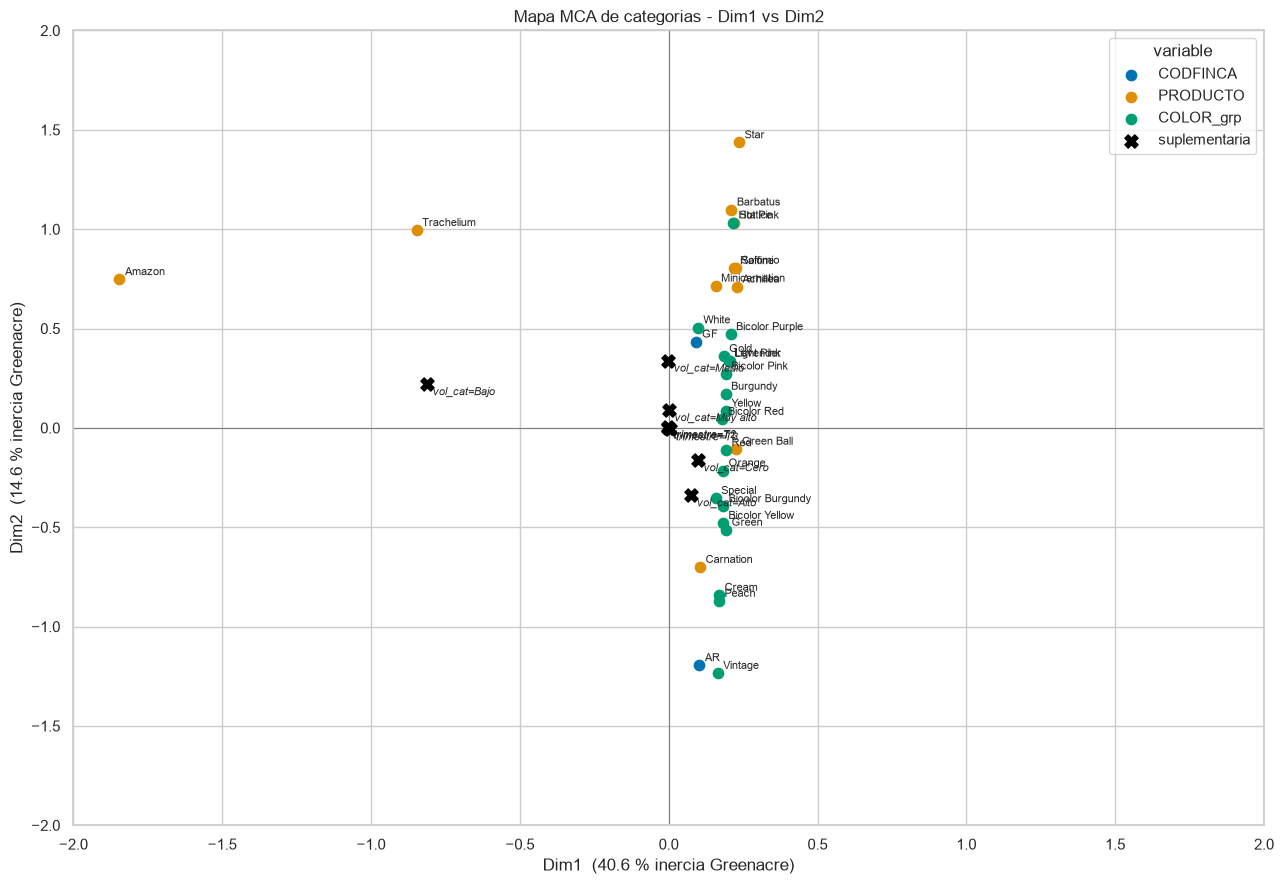

In [9]:
# El eje 1 aisla el nicho CABANA / Eryngium. Recortamos para ver la nube principal.
mapa_categorias(mca, 0, 1, recorte=2.0)

In [10]:
display(Markdown(
    "**Lectura de negocio.**\n\n"
    "- **Dim1** separa el nicho **CABAÑA - Eryngium - Purple** (un único producto en una única finca) "
    "del resto del catálogo. Es una dimensión de *outlier*: informativa (confirma que CABAÑA es "
    "monoproducto) pero domina la escala. Por eso el segundo mapa recorta los ejes.\n"
    "- **Dim2** ordena el grueso del catálogo: opone los **claveles y miniclaveles de GF** "
    "(Carnation, Minicarnation) frente a las **flores de complemento y follaje de AR** "
    "(Solomio, Barbatus, Statice, Veronica).\n"
    "- Las suplementarias de **trimestre** caen casi en el origen: el mix finca-producto-color del "
    "estimado **no cambia con la estacionalidad** dentro de H1.\n"
    "- Las suplementarias de **volumen** sí se despliegan: 'Bajo' se aleja hacia el cuadrante de los "
    "productos de complemento, señal de que esas líneas se estiman en cantidades menores."
))

**Lectura de negocio.**

- **Dim1** separa el nicho **CABAÑA - Eryngium - Purple** (un único producto en una única finca) del resto del catálogo. Es una dimensión de *outlier*: informativa (confirma que CABAÑA es monoproducto) pero domina la escala. Por eso el segundo mapa recorta los ejes.
- **Dim2** ordena el grueso del catálogo: opone los **claveles y miniclaveles de GF** (Carnation, Minicarnation) frente a las **flores de complemento y follaje de AR** (Solomio, Barbatus, Statice, Veronica).
- Las suplementarias de **trimestre** caen casi en el origen: el mix finca-producto-color del estimado **no cambia con la estacionalidad** dentro de H1.
- Las suplementarias de **volumen** sí se despliegan: 'Bajo' se aleja hacia el cuadrante de los productos de complemento, señal de que esas líneas se estiman en cantidades menores.

## 5. Contribuciones y calidad de representación

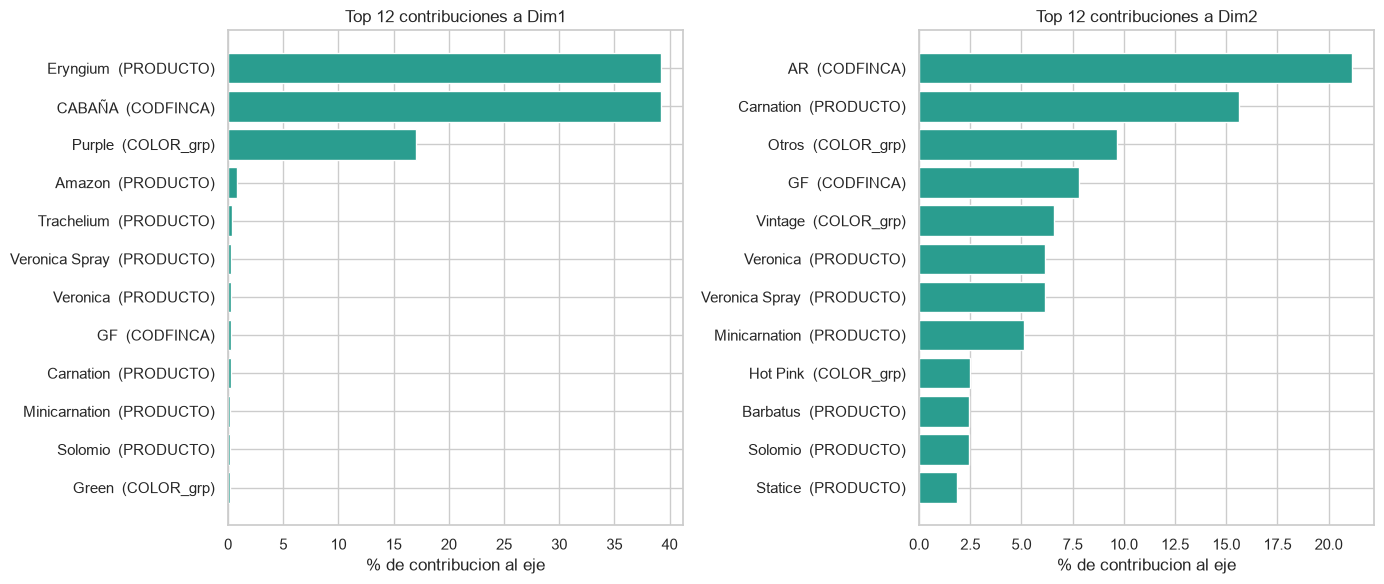

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for k, ax in zip([0, 1], axes):
    s = (pd.Series(mca["contrib"][:, k] * 100, index=mca["categorias"])
         .sort_values(ascending=False).head(12).iloc[::-1])
    etiquetas = [c.split("=", 1)[1] + "  (" + c.split("=", 1)[0] + ")" for c in s.index]
    ax.barh(etiquetas, s.values, color="#2A9D8F")
    ax.set(title=f"Top 12 contribuciones a Dim{k + 1}", xlabel="% de contribucion al eje")
plt.tight_layout()
plt.show()

In [12]:
cos2_plano = mca["cos2"][:, [0, 1]].sum(axis=1)
tabla_cos2 = (pd.DataFrame({
    "variable": mca["var_de_categoria"],
    "categoria": [c.split("=", 1)[1] for c in mca["categorias"]],
    "cos2_Dim1": mca["cos2"][:, 0],
    "cos2_Dim2": mca["cos2"][:, 1],
    "cos2_plano_1_2": cos2_plano,
}).sort_values("cos2_plano_1_2"))
print("Categorias PEOR representadas en el plano Dim1-Dim2 (no sobre-interpretar su posicion):")
display(tabla_cos2.head(10))
print("Categorias MEJOR representadas:")
display(tabla_cos2.tail(10).iloc[::-1])

Categorias PEOR representadas en el plano Dim1-Dim2 (no sobre-interpretar su posicion):


,variable,categoria,cos2_Dim1,cos2_Dim2,cos2_plano_1_2
20,COLOR_grp,Bicolor Red,0.001,0.000,0.001
8,PRODUCTO,Green Ball,0.001,0.000,0.001
22,COLOR_grp,Burgundy,0.001,0.001,0.001
37,COLOR_grp,Yellow,0.002,0.000,0.003
34,COLOR_grp,Special,0.001,0.003,0.003
18,COLOR_grp,Bicolor Pink,0.001,0.002,0.003
33,COLOR_grp,Red,0.003,0.001,0.004
17,COLOR_grp,Bicolor Burgundy,0.001,0.003,0.004
24,COLOR_grp,Gold,0.001,0.004,0.005
29,COLOR_grp,Orange,0.003,0.004,0.006


Categorias MEJOR representadas:


,variable,categoria,cos2_Dim1,cos2_Dim2,cos2_plano_1_2
7,PRODUCTO,Eryngium,0.896,0.003,0.899
1,CODFINCA,CABAÑA,0.896,0.003,0.899
6,PRODUCTO,Carnation,0.014,0.623,0.637
2,CODFINCA,GF,0.024,0.507,0.531
0,CODFINCA,AR,0.004,0.502,0.506
32,COLOR_grp,Purple,0.413,0.001,0.414
30,COLOR_grp,Otros,0.002,0.172,0.174
35,COLOR_grp,Vintage,0.002,0.126,0.128
15,PRODUCTO,Veronica,0.007,0.109,0.116
16,PRODUCTO,Veronica Spray,0.007,0.109,0.116


## 6. Lectura por observación

Cada estimado individual proyectado sobre el plano, coloreado por finca. Muestra cómo las tres fincas ocupan regiones distintas del catálogo.

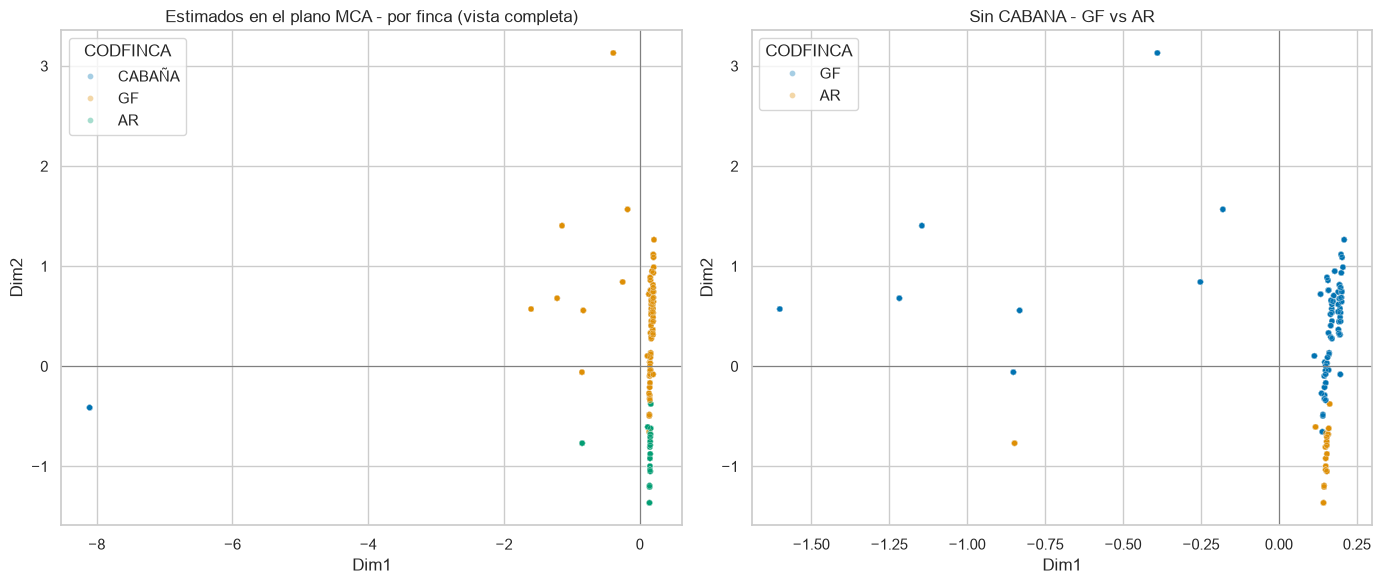

In [13]:
coords_obs = pd.DataFrame({
    "Dim1": mca["coords_row"][:, 0],
    "Dim2": mca["coords_row"][:, 1],
    "CODFINCA": df["CODFINCA"].values,
    "PRODUCTO": df["PRODUCTO"].values,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=coords_obs, x="Dim1", y="Dim2", hue="CODFINCA",
                alpha=0.35, s=18, ax=axes[0])
axes[0].set_title("Estimados en el plano MCA - por finca (vista completa)")
sns.scatterplot(data=coords_obs[coords_obs["CODFINCA"] != "CABAÑA"],
                x="Dim1", y="Dim2", hue="CODFINCA", alpha=0.35, s=18, ax=axes[1])
axes[1].set_title("Sin CABANA - GF vs AR")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.8)
    ax.axvline(0, color="grey", lw=0.8)
plt.tight_layout()
plt.show()

## 7. Conclusiones

### Lo que revela el MCA

- El catálogo estimado en H1 se organiza en **dos ejes claros**: (1) el nicho monoproducto de **CABAÑA (Eryngium)** frente a todo lo demás, y (2) la oposición entre el bloque **clavel / miniclavel de GF** y el bloque **flores de complemento y follaje de AR**.
- **Finca, producto y color están fuertemente acoplados**: conocer la finca predice en gran medida el producto y la gama de color. Las tres fincas ocupan regiones casi disjuntas del plano (sección 6).
- El **volumen** estimado (variable suplementaria) se alinea con esa estructura: las líneas de complemento se estiman en cantidades sistemáticamente menores.
- El **trimestre** no aporta separación: la composición del estimado por finca-producto-color es estable a lo largo de H1; la estacionalidad actúa sobre las cantidades, no sobre el mix de categorías.

### Lo que este análisis no demuestra

- El MCA describe **cómo el ingeniero arma el estimado**, no la demanda real ni el acierto de la predicción (eso es el notebook `03`).
- La proximidad entre categorías es **co-ocurrencia en el catálogo**, no causalidad ni sustituibilidad comercial.
- Se excluyó `VARIEDAD` (150 niveles) y se agruparon los colores raros: una lectura a nivel de variedad requeriría un MCA específico por finca o un análisis de correspondencias simple finca x variedad.
- Las correcciones de Benzécri/Greenacre mejoran la interpretación del % de inercia pero siguen siendo aproximaciones; las conclusiones se apoyan en la **posición relativa** de las categorías, no en umbrales numéricos exactos.